## Задание 1. (1 балл)

Посчитайте частоты для 5-грамм в корпусе lenta.txt. двумя способами:  
1) Текст токенизируется в один сплошной список токенов и нграммы считаются по всем токенам без учета границ предложений
2) Текст разбивается на предложения, а каждое предложение на токены; нграммы собираются с учетом границ предложений
    
Найдите различия между топ 100 нграммов для первого и второго способов

In [1]:
from collections import Counter
from itertools import islice
from pathlib import Path
from urllib.request import urlretrieve
import math
import re
import zipfile

archive_path = Path('lenta.txt.zip')
if not archive_path.exists():
    urlretrieve(
        'https://raw.githubusercontent.com/mannefedov/compling_nlp_hse_course/master/data/lenta.txt.zip',
        archive_path,
    )

with zipfile.ZipFile(archive_path) as archive:
    file_name = next(name for name in archive.namelist() if name.endswith('.txt'))
    text = archive.read(file_name).decode('utf-8')

def tokenize(text):
    return re.findall(r'[а-яёa-z]+(?:-[а-яёa-z]+)?', text.lower())

def ngrams(tokens, n):
    return zip(*(islice(tokens, offset, None) for offset in range(n)))

tokens = tokenize(text)
sentences = [tokenize(sentence) for sentence in re.split(r'[.!?]+', text) if sentence.strip()]

flat_5grams = Counter(ngrams(tokens, 5))
sentence_5grams = Counter(gram for sentence in sentences for gram in ngrams(sentence, 5))

top_flat = flat_5grams.most_common(100)
top_sentence = sentence_5grams.most_common(100)
flat_top_grams = {gram for gram, _ in top_flat}
sentence_top_grams = {gram for gram, _ in top_sentence}

print(f'Токенов: {len(tokens):,}; предложений: {len(sentences):,}')
print(f'Совпадающих 5-грамм в топ-100: {len(flat_top_grams & sentence_top_grams)}')
print('\nТолько в топ-100 без границ предложений:')
for gram in sorted(flat_top_grams - sentence_top_grams, key=lambda gram: (-flat_5grams[gram], gram)):
    print(f"{' '.join(gram)} — {flat_5grams[gram]}")

print('\nТолько в топ-100 с границами предложений:')
for gram in sorted(sentence_top_grams - flat_top_grams, key=lambda gram: (-sentence_5grams[gram], gram)):
    print(f"{' '.join(gram)} — {sentence_5grams[gram]}")


Токенов: 1,476,951; предложений: 90,093
Совпадающих 5-грамм в топ-100: 94

Только в топ-100 без границ предложений:
сообщает риа новости по словам — 35
возбуждено уголовное дело ведется следствие — 26
передает риа новости по словам — 25
и о президента владимир путин — 22
сообщает риа новости по данным — 20
в по московскому времени в — 19

Только в топ-100 с границами предложений:
борьбе с организованной преступностью мвд — 18
в то же время в — 18
заместитель начальника генерального штаба вооруженных — 18
по борьбе с экономическими преступлениями — 18
представителя правительства рф в чечне — 18
сообщили риа новости в пресс-центре — 18


## Задание 2. (1 балл)

Найдите какую-то инетересную (по вашему мнению) закономерность на https://books.google.com/ngrams/ для русского языка (с 1990 по 2022)

Вставьте сюда скриншот

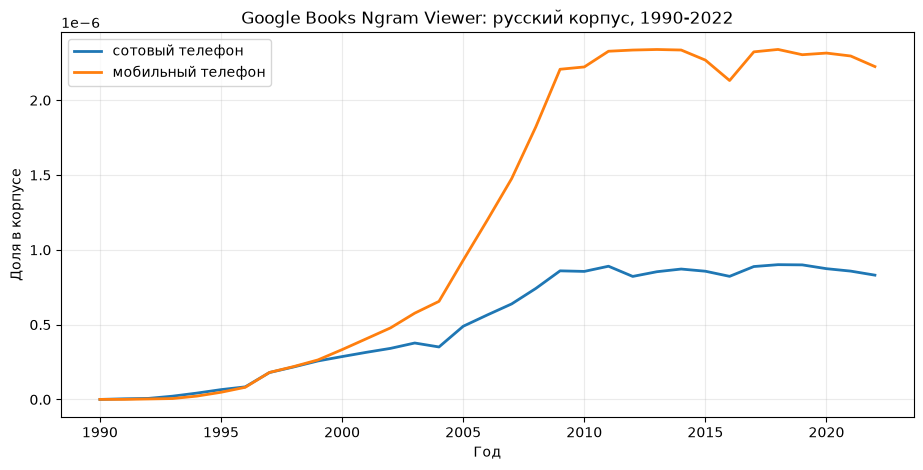

После середины 2000-х «мобильный телефон» устойчиво встречается примерно в 2,5 раза чаще «сотового телефона».
Похоже, в книжном русском языке закрепилось более широкое обозначение устройства, а не типа связи.
https://books.google.com/ngrams/json?content=%D1%81%D0%BE%D1%82%D0%BE%D0%B2%D1%8B%D0%B9+%D1%82%D0%B5%D0%BB%D0%B5%D1%84%D0%BE%D0%BD%2C%D0%BC%D0%BE%D0%B1%D0%B8%D0%BB%D1%8C%D0%BD%D1%8B%D0%B9+%D1%82%D0%B5%D0%BB%D0%B5%D1%84%D0%BE%D0%BD&year_start=1990&year_end=2022&corpus=ru&smoothing=3


In [ ]:
import json
from urllib.parse import urlencode
from urllib.request import urlopen
import matplotlib.pyplot as plt

query = {
    'content': 'сотовый телефон,мобильный телефон',
    'year_start': 1990,
    'year_end': 2022,
    'corpus': 'ru',
    'smoothing': 3,
}
url = 'https://books.google.com/ngrams/json?' + urlencode(query)
with urlopen(url) as response:
    data = json.load(response)

years = list(range(1990, 2023))
plt.figure(figsize=(11, 5))
for item in data:
    plt.plot(years, item['timeseries'], label=item['ngram'], linewidth=2)
plt.title('Google Books Ngram Viewer: русский корпус, 1990-2022')
plt.xlabel('Год')
plt.ylabel('Доля в корпусе')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print('После середины 2000-х «мобильный телефон» устойчиво встречается примерно в 2,5 раза чаще «сотового телефона».')
print('Похоже, в книжном русском языке закрепилось более широкое обозначение устройства, а не типа связи.')
print(url)


## Заданиe 3 (1 балл)

В семинаре мы использовали Dice coefficient (`score = 2 * bigram_count/((word_count_a+word_count_b))`) для нахождения коллокаций.
Но самая известная метрика для этого другая - [PMI](https://en.wikipedia.org/wiki/Pointwise_mutual_information). Имплементируйте скоринг с помощью этой метрики и сравните результаты с Dice на топ 30 биграмах.
Используйте логарифмы для работы с вероятностями.

In [ ]:
def scorer_dice(bigram_count, word_count_a, word_count_b):
    return 2 * bigram_count / (word_count_a + word_count_b)

def scorer_pmi(bigram_count, word_count_a, word_count_b, total_bigrams, total_words):
    try:
        return math.log2((bigram_count / total_bigrams) / ((word_count_a / total_words) * (word_count_b / total_words)))
    except ZeroDivisionError:
        return 0

word_counts = Counter(tokens)
bigram_counts = Counter(ngrams(tokens, 2))
top_bigrams = bigram_counts.most_common(30)

print(f"{'Биграмма':<42} {'Частота':>8} {'Dice':>10} {'PMI':>10}")
for (first, second), count in top_bigrams:
    dice = scorer_dice(count, word_counts[first], word_counts[second])
    pmi = scorer_pmi(count, word_counts[first], word_counts[second], len(tokens) - 1, len(tokens))
    print(f"{first + ' ' + second:<42} {count:>8} {dice:>10.4f} {pmi:>10.4f}")

print('\nDice сильнее выделяет биграммы из редких слов с сопоставимыми частотами; PMI оценивает отклонение от независимой встречаемости.')


Биграмма                                    Частота       Dice        PMI
риа новости                                    3504     0.9861     8.6791
по словам                                      1971     0.1753     5.6411
об этом                                        1795     0.5654     8.0407
что в                                          1624     0.0363     0.9598
а также                                        1400     0.3295     6.8419
сообщает риа                                   1326     0.3269     6.9205
в чечне                                        1260     0.0342     4.2380
со ссылкой                                     1253     0.6306     9.0818
ссылкой на                                     1247     0.0840     5.6875
в результате                                   1225     0.0333     4.3432
как сообщает                                   1218     0.2012     5.7039
по его                                         1216     0.0997     4.2305
том что                               

# Задание 4 (2 балл)

Шаг 1: Измените функцию merge_round так чтобы она использовала скоринг, который вы сделаете в задании выше.
Шаг 2: Подберите параметры (min_count, n_merges, n_rounds) так чтобы получались адекватные результаты
Шаг 3: Сохраните промежуточные словари мержей и напишите функцию, которая их последовательно применяет, чтобы иметь возможности воспроизвести трансформацию на любой новом тексте

Подберите несколько предложений, на которых функция трансформации будет склеивать хотя бы несколько слов вместе

In [ ]:
def merge_round(corpus, min_count=20, n_merges=25):
    unigram_counts = Counter(corpus)
    bigram_counts = Counter(ngrams(corpus, 2))
    candidates = []
    for (first, second), count in bigram_counts.items():
        if count >= min_count:
            score = scorer_pmi(count, unigram_counts[first], unigram_counts[second], len(corpus) - 1, len(corpus))
            candidates.append(((first, second), score))

    selected = dict(sorted(candidates, key=lambda item: item[1], reverse=True)[:n_merges])
    merges = {pair: '_'.join(pair) for pair in selected}
    merged_corpus = []
    index = 0
    while index < len(corpus):
        pair = tuple(corpus[index:index + 2])
        if pair in merges:
            merged_corpus.append(merges[pair])
            index += 2
        else:
            merged_corpus.append(corpus[index])
            index += 1
    return merged_corpus, merges

sub_corpus = tokens
saved_merged = []
for round_i in range(5):
    sub_corpus, merges = merge_round(sub_corpus, min_count=20, n_merges=25)
    saved_merged.append(merges)
    print(f'Раунд {round_i + 1}: {len(merges)} мержей')

def apply_merges(text, saved_merged):
    merged_text = text
    for merges in saved_merged:
        result = []
        index = 0
        while index < len(merged_text):
            pair = tuple(merged_text[index:index + 2])
            if pair in merges:
                result.append(merges[pair])
                index += 2
            else:
                result.append(merged_text[index])
                index += 1
        merged_text = result
    return merged_text


Раунд 1: 25 мержей


Раунд 2: 25 мержей


Раунд 3: 25 мержей


Раунд 4: 25 мержей


Раунд 5: 25 мержей


In [ ]:
for round_i, merges in enumerate(saved_merged, start=1):
    print(f'\nМержи раунда {round_i}:')
    print(', '.join(merges.values()))

examples = [
    'Газета Wall Street Journal сообщила о новых торгах.',
    'Представители Русской православной церкви выступили с заявлением.',
    'Обсуждается увеличение минимального размера оплаты труда.',
]

for example in examples:
    print(f'\n{example}')
    print(apply_merges(tokenize(example), saved_merged))



Мержи раунда 1:
exit_polls, норильский_никель, духовное_наследие, взрывном_устройстве, подписные_листы, dow_jones, эхуд_барак, персидского_залива, всея_руси, кофи_аннан, манчестер_юнайтед, амана_тулеева, смертной_казни, подписных_листов, ak_m, шкале_рихтера, саудовской_аравии, мобильном_отряде, персидском_заливе, general_motors, террористического_акта, лорд_рассел-джонстон, борису_ельцину, ростове-на_дону, следственном_изоляторе

Мержи раунда 2:
восточном_тиморе, ближнем_востоке, чрезвычайных_ситуаций, wall_street, верховной_рады, восточного_тимора, взрывчатого_вещества, борисом_ельциным, следственный_изолятор, аргунского_ущелья, street_journal, золотовалютных_резервов, константина_титова, голубой_поток, герман_греф, населенном_пункте, нобелевской_премии, france_presse, полевые_командиры, соединенные_штаты, стихийного_бедствия, минимального_размера, генеральную_прокуратуру, правоохранительным_органам, сибирский_алюминий

Мержи раунда 3:
wall_street_journal, асланом_масхадовым, космодр

# Задание 5 (3 балла)

Напишите краткое эссе (30 - 50 предложений) в свободной форме по одной из этих статей:
1) https://news.microsoft.com/source/2026/09/09/aft-uft-and-microsoft-announce-national-ai-safety-privacy-standard-for-schools-to-protect-students-families-and-educators/ и сам целый документ https://www.aft.org/sites/default/files/media/documents/2026/NAfAI-School_AI_Privacy_Standards.pdf
2) https://bayareacurrent.com/theres-a-lot-of-cleaning-up-poop-a-depot-worker-on-the-human-labor-behind-waymos-autonomous-vehicles/

Эту часть достаточно сложно оценивать формально, но я ожидаю увидеть ваши содержательные рассуждения о написанном в статье.   
Если после прочтения вам ничего не приходит в голову, то вы можете начать со следующих вопросов: Считаете ли вы эту информацию важной/интересной/страшной/скучной/и тп? Что показалось вам наиболее важным? Почему? Считаете ли вы эту статью объективной? Какие пробелы вы видите? По вашему мнению будет ли продолжение у этих историй? В каком направлении они будут развиваться? Считаете ли вы age restriction необходимым для AI моделей? (для первой статьи) Как можно предотвращать/бороться с подобным антисоциальным поведением в автономных автомобилях? (для второй) ...
Но это не полный и не обязательный список! Вы можете писать о всем, что вы посчитаете нужным.

Чего точно следует избегать:
1) Не пишите саммари! Ваше эссе должно выражать ваши собственные мысли и добавлять что-то к тексту, а не заменять его.
2) Не гонитесь за полнотой! Можно и нужно опускать детали. Вы даже можете даже сфокусироваться только на каком-то одном аспекте статьи и порассуждать о нем поглубже.
3) Не отвлекайтесь на форматирование! Не используйте нумерованные списки, булет пойнты, ссылки и т.п. Напишите все как один связанный plain текст (можете разбить все на параграфы, но не более того)
4) Не объясняйте термины и понятия, не давайте определений! Считайте, что читатель знает столько же, сколько вы или же что он может погуглить.
5) Не уходите от темы! Реагируйте только на сам текст, а не на общий контекст (схожие события и работы, реакция в сотсетях и т.п). Не сравнивайте с другими статьями от того же Антропика или OpenAI.
6) Не бойтесь выражать мнение! Но либо обосновывайте его, либо описиваете свои ощущения в деталях.
7) Будьте осторожными с bias. Не списывайте все на капитализм, AI buble, AI doomerism, AI accerationalism и тому подобные слишком общие и абстрактные вещи. Не выражайте ваше личное отношение к авторам (антропику), только к содержанию статьи!



Это эссе могло бы быть о том, что автономная система в очередной раз оказалась не до конца автономной. Но такие заголовки в новостях, честно говоря, уже приелись. Поэтому я слегка изменю этот тезис, возможно, даже сделав его немного оптимистичнее: ИИ не заменил человека в какой-то сфере, а забрал себе 1 задачу и создал вокруг себя 10 новых.
Как и в эпоху предыдущих технореволюций, сейчас многие люди опасаются, что их уволят с работы, потому что умный ИИ может делать ее бесплатно (ну или по крайней мере дешевле, если считать токены). Однако на примере некоторых профессий мы видим, что работа человека просто переходит на новый уровень абстракции (например, работа программиста с агентами). А на примере других, как в этом репортаже, мы можем наблюдать ситуацию, где профессия в привычном понимании действительно стала требовать сильно меньше человеческих рабочих рук, но при этом появилось множество других смежных профессий.
Хоть операторы беспилотных машин технически и являются водителями, очевидно, что количество трудоустроенных на эту должность людей сильно меньше, чем было трудоустроено таксистов в привычном понимании этого слова еще несколько лет назад. Нет оснований полагать, что со временем это число не станет еще мизернее. Однако для обслуживания беспилотных автомобилей потребовались люди, которые не требовались для обслуживания обычных такси. Это создало новые рабочие места.
Меня также заинтересовал тезис, высказанный сотрудником Waymo. “Half of us don’t really do that much. But we’re hired for our capacity to do labor and not for our labor itself.” В системе беспилотного такси человек стал по сути fallback-ом. Возможно, в будущем большая часть существующего человеческого труда станет именно такой: эксперт на случай, если ИИ не справится. К сожалению, в текущем состоянии вещей для сотрудников это не значит, что они могут 90% времени не работать и отдыхать, так как непонятно, когда возникнет необходимость в fallback-e. Но мне нравится сама идея о том, что таким образом 8-часовой рабочий день может стать пережитком прошлого.
Впрочем, достаточно позитива, давайте посмотрим на негативные стороны этой новой возникшей инфраструктуры. По сути негативным сторонам и посвящено все интервью. Вопросы, адресованные работнику, связаны только с плохими аспектами его работы в компании. Поэтому его глазами появившуюся вокруг беспилотных машин индустрию мы видим, как клубок хаоса и грязи: непонятное устройство компании, неадекватные клиенты, доносы коллег, глупые правила и потребительское отношение к сотрудникам.
Чем-то новым это все, конечно, не является, но мы можем помечтать о том, что можно изменить в этой системе к лучшему. Как исправлять внутреннее устройство компании, я судить не берусь, поэтому поговорим про антисоциальное поведение.
Логично, что люди, которые находятся в машине в одиночестве, могут начать творить беспредел. Но как это предотвратить? Первыми на ум приходят временные баны и повышения цены поездки, но можно предусмотреть и пряник вместо кнута. Можно начать рекламировать такие услуги, как поездки премиум класса в полном комфорте, намеренно показывать в роликах, как внутри чисто и дорого. В такой атмосфере клиенты с меньшей вероятностью будут вести себя маргинально. Хорошим методом предотвращения таких ситуаций мне кажется также и огласка в прессе нескольких громких случаев: кто-то нанес машине ущерб и понес реальные последствия, а потом об этом рассказали в новостях.
В завершение хочу сказать, что эта область скорее всего будет развиваться по такому сценарию: беспилотные такси вытеснят обычные за счет снижения цен, а затем снова повысят их. Количество человеческого труда с некоторой вероятностью меняться вообще не будет, однако люди будут заняты на все более и более fallback областях: дистанционный водитель автомобиля на случай проблемы, затем дистанционный водитель робота уборщика машины на случай проблемы и так далее.

